# Proceso de Machine Learning

## Selección del mejor Dataset

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

import warnings

warnings.filterwarnings("ignore", category=UserWarning)

X_train_CON_outliers = pd.read_excel("../data/processed/X_train_CON_outliers.xlsx")
X_train_CON_outliers_norm = pd.read_excel("../data/processed/X_train_CON_outliers_norm.xlsx")
X_train_CON_outliers_scal = pd.read_excel("../data/processed/X_train_CON_outliers_scal.xlsx")
X_train_SIN_outliers = pd.read_excel("../data/processed/X_train_SIN_outliers.xlsx")
X_train_SIN_outliers_norm = pd.read_excel("../data/processed/X_train_SIN_outliers_norm.xlsx")
X_train_SIN_outliers_scal = pd.read_excel("../data/processed/X_train_SIN_outliers_scal.xlsx")

y_train = pd.read_excel("../data/processed/y_train.xlsx")
y_train = y_train.squeeze()

#Utilizaremos el modelo de regresion lineal
datasets = [X_train_CON_outliers,
    X_train_CON_outliers_norm,
    X_train_CON_outliers_scal,
    X_train_SIN_outliers,
    X_train_SIN_outliers_norm,
    X_train_SIN_outliers_scal
    ]

metrics = []

for dataset in datasets:
    model = KNeighborsClassifier(n_neighbors=5) #ML class
    metric = cross_val_score(model, dataset, y_train, cv = 5) # Al utilizar el k=1 y accuracy score todos daban = 1
    metrics.append(metric.mean())

best_metric = max(metrics)
best_index = metrics.index(best_metric)
print(f"El mejor dataset es: \n{datasets[best_index]}")

El mejor dataset es: 
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0          0.123894          0.267123         0.00        0.082192   0.086811   
1          0.353982          0.205479         0.39        0.061644   0.093489   
2          0.238938          0.369863         0.00        0.075342   0.120200   
3          0.398230          0.116438         0.33        0.078767   0.085142   
4          0.141593          0.232877         0.17        0.047945   0.101836   
...             ...               ...          ...             ...        ...   
1274       0.300885          0.273973         0.25        0.075342   0.110184   
1275       0.610619          0.205479         0.48        0.116438   0.108514   
1276       0.212389          0.178082         0.49        0.109589   0.141903   
1277       0.477876          0.157534         0.47        0.075342   0.081803   
1278       0.212389          0.328767         0.30        0.246575   0.093489   

     

### Gráficos entre variables

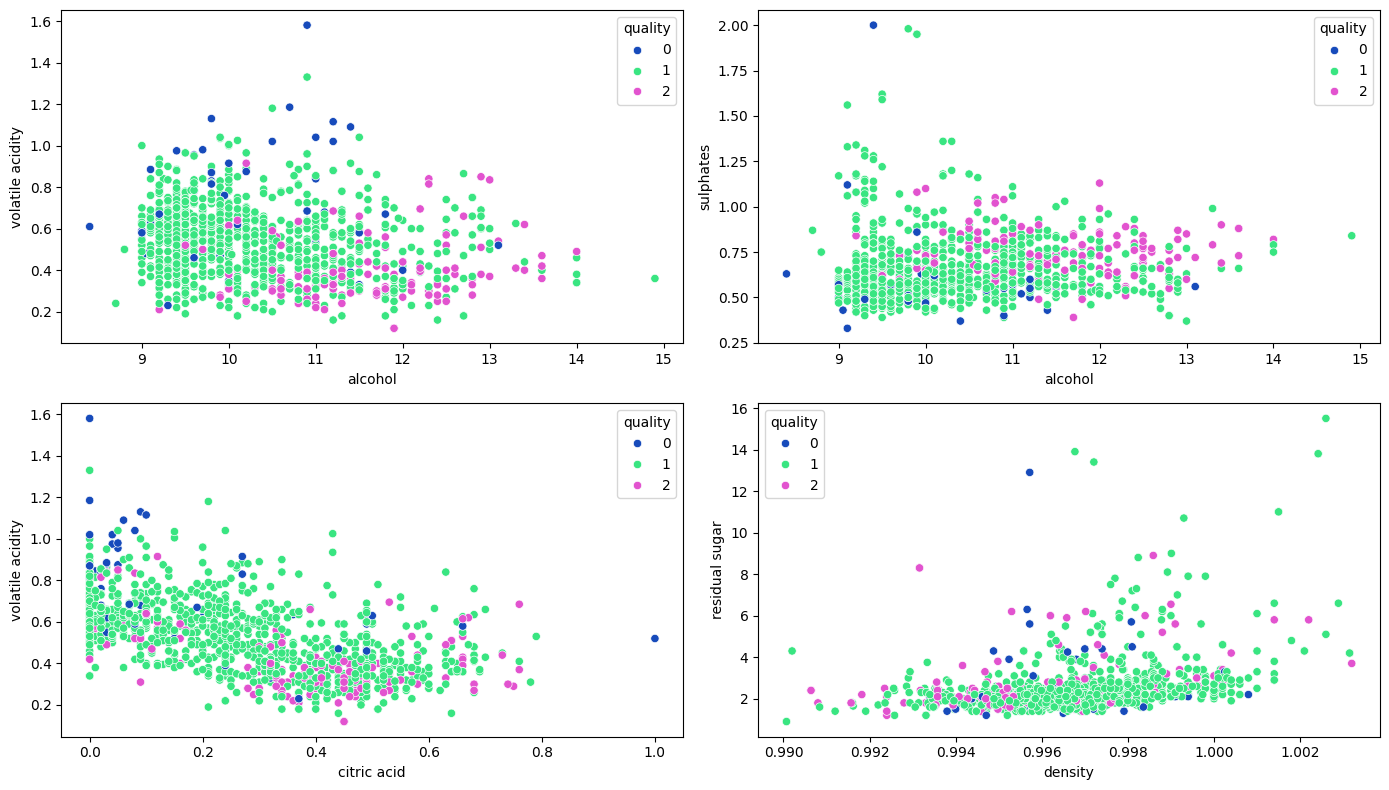

In [109]:
#Como ejemplo de grafico se utilizara el df_con_outliers

df_relaciones = X_train_CON_outliers.copy()
df_relaciones["quality"] = y_train.values

fig, axis = plt.subplots(2, 2, figsize = (14, 8))

palette = ["#174BBB", "#39E581", "#E253CF"]

sns.scatterplot(ax = axis[0, 0], data = df_relaciones, x = "alcohol", y = "volatile acidity", hue="quality", palette=palette)
sns.scatterplot(ax = axis[0, 1], data = df_relaciones, x = "alcohol", y = "sulphates", hue="quality", palette=palette)
sns.scatterplot(ax = axis[1, 0], data = df_relaciones, x = "citric acid", y = "volatile acidity", hue="quality", palette=palette)
sns.scatterplot(ax = axis[1, 1], data = df_relaciones, x = "density", y = "residual sugar", hue="quality", palette=palette)

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

### Métricas del mejor dataset para k=5

In [110]:
model = KNeighborsClassifier(n_neighbors=5) #ML class
model.fit(dataset, y_train)
y_pred = model.predict(datasets[best_index])
metric1 = accuracy_score(y_train, y_pred)
metric2 = confusion_matrix(y_train, y_pred)
metric3 = classification_report(y_train, y_pred, zero_division=0)
print(f"accuracy: {metric1}\n")
print(f"Confusion matrix: \n {metric2}\n")
print(f"Classification report: \n {metric3}")


accuracy: 0.8162627052384676

Confusion matrix: 
 [[   0   51    1]
 [   0 1032   28]
 [   0  155   12]]

Classification report: 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        52
           1       0.83      0.97      0.90      1060
           2       0.29      0.07      0.12       167

    accuracy                           0.82      1279
   macro avg       0.38      0.35      0.34      1279
weighted avg       0.73      0.82      0.76      1279



## Mejor valor de k

Al utilizar k=1 con el accuracy_score, ese valor siempre daba como resultado 1. No es normal una precisión perfecta, por lo cual se realizara con cross_validation_score.

Mejor valor de k: 16


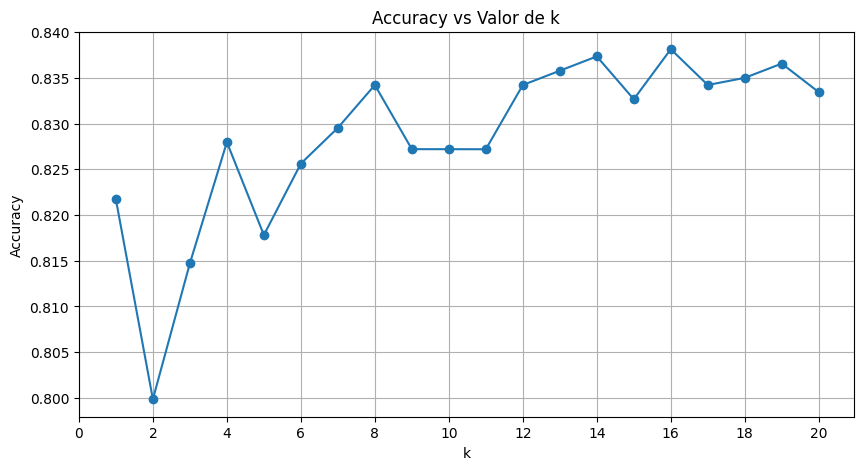

In [111]:
acc_por_valor_k_=[]
k_range = range(1, 21)
k_range_grafico = range(0, 22, 2)

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    metric = cross_val_score(model, dataset, y_train, cv = 5)

    acc_por_valor_k_.append(metric.mean())


best_k = k_range[acc_por_valor_k_.index(max(acc_por_valor_k_))]
print(f"Mejor valor de k: {best_k}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, acc_por_valor_k_, marker='o')
plt.title("Accuracy vs Valor de k")
plt.xticks(k_range_grafico)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Optimización de hiperparámetros

In [112]:
params = {
    "n_neighbors": [4, 8, 14, 16],
    "weights": ["uniform"], # Al aplicar el segundo parametro llamado distance el modelo empieza a "decir que todo es si" dando un accuracy de 1.0, por lo cual con el uniform se puede forzar al modelo a funcionar
    "algorithm":["auto", "ball_tree", "kd_tree", "brute"],
    "leaf_size": [20, 30, 40],
    "p": [1, 2, 3],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

### Grid search

In [113]:
grid = GridSearchCV(KNeighborsClassifier(), params, scoring="f1_weighted", cv = 5, n_jobs = -1)
grid.fit(datasets[best_index], y_train)
print(grid.best_params_)
best_model = grid.best_estimator_
print("El mejor estimador es: ", best_model)
print("La mejor puntuación es: ", grid.best_score_)

{'algorithm': 'auto', 'leaf_size': 20, 'metric': 'euclidean', 'n_neighbors': 4, 'p': 1, 'weights': 'uniform'}
El mejor estimador es:  KNeighborsClassifier(leaf_size=20, metric='euclidean', n_neighbors=4, p=1)
La mejor puntuación es:  0.8083869528688284


### Random search

In [114]:
grid = RandomizedSearchCV(KNeighborsClassifier(), params, scoring="f1_weighted", cv = 5, n_iter = 30, n_jobs = -1)
grid.fit(datasets[best_index], y_train)
print(grid.best_params_)
best_model = grid.best_estimator_
print(best_model)
print("El mejor estimador es: ", best_model)
print("La mejor puntuación es: ", grid.best_score_)

{'weights': 'uniform', 'p': 1, 'n_neighbors': 4, 'metric': 'euclidean', 'leaf_size': 40, 'algorithm': 'auto'}
KNeighborsClassifier(leaf_size=40, metric='euclidean', n_neighbors=4, p=1)
El mejor estimador es:  KNeighborsClassifier(leaf_size=40, metric='euclidean', n_neighbors=4, p=1)
La mejor puntuación es:  0.8083869528688284


## Métricas finales

In [115]:
X_test_CON_outliers = pd.read_excel("../data/processed/X_test_CON_outliers.xlsx")
X_test_CON_outliers_norm = pd.read_excel("../data/processed/X_test_CON_outliers_norm.xlsx")
X_test_CON_outliers_scal = pd.read_excel("../data/processed/X_test_CON_outliers_scal.xlsx")
X_test_SIN_outliers = pd.read_excel("../data/processed/X_test_SIN_outliers.xlsx")
X_test_SIN_outliers_norm = pd.read_excel("../data/processed/X_test_SIN_outliers_norm.xlsx")
X_test_SIN_outliers_scal = pd.read_excel("../data/processed/X_test_SIN_outliers_scal.xlsx")

y_test = pd.read_excel("../data/processed/y_test.xlsx")
y_test = y_test.squeeze()

datasets_test = [X_test_CON_outliers,
    X_test_CON_outliers_norm,
    X_test_CON_outliers_scal,
    X_test_SIN_outliers,
    X_test_SIN_outliers_norm,
    X_test_SIN_outliers_scal
    ]


model_f = KNeighborsClassifier(leaf_size=20, metric='euclidean', n_neighbors=4, p=1)
model_f.fit(datasets[best_index], y_train)

y_pred = model_f.predict(datasets[best_index])
metric_train = accuracy_score(y_train, y_pred)
metric_train2 = confusion_matrix(y_train, y_pred)
metric_train3 = classification_report(y_train, y_pred, zero_division=0)


y_pred = model_f.predict(datasets_test[best_index])
metric_test = accuracy_score(y_test, y_pred)
metric_test2 = confusion_matrix(y_test, y_pred)
metric_test3 = classification_report(y_test, y_pred, zero_division=0)


print(f"La mejor métrica de nuestros datasets x_train son: {metric_train} y los x_test son: {metric_test}")
print(f"La mejor métrica de matriz de confusión con x_train son: \n {metric_train2} \n y los x_test son: \n {metric_test2}")
print(f"Classification resport de x_train son: \n {metric_train3} \n y los x_test son: \n {metric_test3}")

#Guardar modelo
filename = "../models/knn_wine_quality_no_distance_param_f1_weighted_v1.pkl"
with open(filename, 'wb') as archivo:
    pickle.dump(model_f, archivo)

La mejor métrica de nuestros datasets x_train son: 0.8928850664581705 y los x_test son: 0.81875
La mejor métrica de matriz de confusión con x_train son: 
 [[  20   30    2]
 [   5 1039   16]
 [   0   84   83]] 
 y los x_test son: 
 [[  1  10   0]
 [  6 242  11]
 [  0  31  19]]
Classification resport de x_train son: 
               precision    recall  f1-score   support

           0       0.80      0.38      0.52        52
           1       0.90      0.98      0.94      1060
           2       0.82      0.50      0.62       167

    accuracy                           0.89      1279
   macro avg       0.84      0.62      0.69      1279
weighted avg       0.89      0.89      0.88      1279
 
 y los x_test son: 
               precision    recall  f1-score   support

           0       0.14      0.09      0.11        11
           1       0.86      0.93      0.89       259
           2       0.63      0.38      0.47        50

    accuracy                           0.82       320
   mac

In [116]:
def predict_wine_quality(wine_params):

    scaler = StandardScaler()
    scaler.fit(datasets[best_index])

    wine_params_scaled = scaler.transform([wine_params])
    pred = model_f.predict(wine_params_scaled)[0]
    
    if pred == 0:
        return "Este vino probablemente sea de baja calidad"
    elif pred == 1:
        return "Este vino probablemente sea de calidad media"
    else:
        return "Este vino probablemente sea de alta calidad"
    
predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])


'Este vino probablemente sea de calidad media'